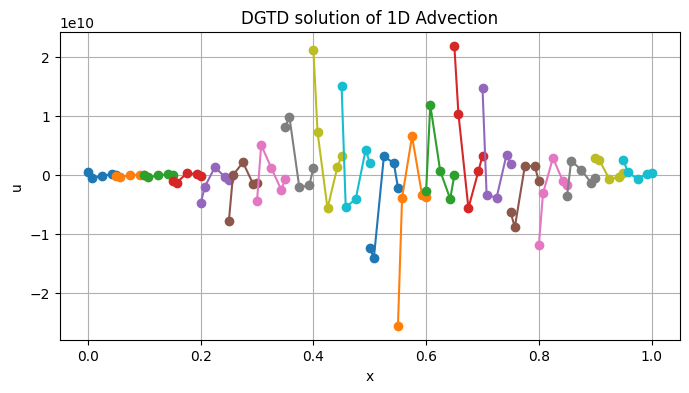

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================
# Parameters
# ==============================================================

a = 1.0                     # advection velocity
xmin = 0.0
xmax = 1.0

Ne = 20                     # number of elements
N = 4                       # polynomial degree
Np = N + 1                  # nodes per element

FinalTime = 1.0

# ==============================================================
# Reference element nodes (Chebyshev-Lobatto approximation)
# ==============================================================

r = -np.cos(np.pi*np.arange(Np)/N)

# ==============================================================
# Lagrange derivative matrix
# ==============================================================

def derivative_matrix(nodes):
    Np = len(nodes)

    w = np.ones(Np)

    for j in range(Np):
        for k in range(Np):
            if j != k:
                w[j] *= (nodes[j]-nodes[k])

    w = 1.0/w

    D = np.zeros((Np,Np))

    for i in range(Np):
        for j in range(Np):
            if i != j:
                D[i,j] = w[j]/w[i]/(nodes[i]-nodes[j])

    for i in range(Np):
        D[i,i] = -np.sum(D[i,:])

    return D

Dr = derivative_matrix(r)

# ==============================================================
# Mass matrix using GLL quadrature
# ==============================================================

weights = np.ones(Np)
weights[0] = 0.5
weights[-1] = 0.5
weights *= np.pi/N

M = np.diag(weights)
Minv = np.diag(1/weights)

# ==============================================================
# Mesh generation
# ==============================================================

VX = np.linspace(xmin,xmax,Ne+1)

x = np.zeros((Ne,Np))

for e in range(Ne):

    xl = VX[e]
    xr = VX[e+1]

    x[e,:] = 0.5*(xr-xl)*r + 0.5*(xr+xl)

J = (VX[1]-VX[0])/2

rx = 1/J

# ==============================================================
# Initial condition
# ==============================================================

u = np.exp(-100*(x-0.3)**2)

# ==============================================================
# Right-hand side
# ==============================================================

def compute_rhs(u):

    rhs = np.zeros_like(u)

    for e in range(Ne):

        # Interior derivative
        ux = rx * (Dr @ u[e])

        rhs[e] = -a*ux

    # Numerical fluxes
    for e in range(Ne):

        em = (e-1)%Ne
        ep = (e+1)%Ne

        # left interface
        uL = u[e,0]
        uR = u[em,-1]

        if a > 0:
            flux = a*uR
        else:
            flux = a*uL

        rhs[e,0] += (flux-a*uL)/weights[0]/J

        # right interface
        uL = u[e,-1]
        uR = u[ep,0]

        if a > 0:
            flux = a*uL
        else:
            flux = a*uR

        rhs[e,-1] -= (flux-a*uL)/weights[-1]/J

    return rhs

# ==============================================================
# Time step
# ==============================================================

dx = (xmax-xmin)/Ne

dt = 0.2*dx/(abs(a)*(2*N+1))

time = 0

# ==============================================================
# RK4
# ==============================================================

while time < FinalTime:

    if time+dt > FinalTime:
        dt = FinalTime-time

    k1 = compute_rhs(u)

    k2 = compute_rhs(u+0.5*dt*k1)

    k3 = compute_rhs(u+0.5*dt*k2)

    k4 = compute_rhs(u+dt*k3)

    u += dt*(k1+2*k2+2*k3+k4)/6

    time += dt

# ==============================================================
# Plot
# ==============================================================

plt.figure(figsize=(8,4))

for e in range(Ne):
    plt.plot(x[e],u[e],'o-')

plt.xlabel("x")
plt.ylabel("u")
plt.title("DGTD solution of 1D Advection")
plt.grid(True)
plt.show()